In [1]:
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd

df = pd.read_csv("../data/processed/user_segments.csv")

print(df['churned_next_30d'].value_counts(normalize=True))

churned_next_30d
0    0.9586
1    0.0414
Name: proportion, dtype: float64


In [2]:
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report, roc_curve
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/user_segments.csv")

churn_features = [
    'obs_avg_sessions_per_week', 'avg_completion_rate', 'genre_diversity',
    'tenure_days', 'obs_recent_30d_sessions', 'obs_prior_30d_sessions', 'obs_session_trend_ratio',
]

X = df[churn_features]
y = df['churned_next_30d']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train churn rate:", y_train.mean())
print("Test churn rate:", y_test.mean())
print("Train size:", len(X_train), "| Test size:", len(X_test))

Train churn rate: 0.0415
Test churn rate: 0.041
Train size: 4000 | Test size: 1000


In [3]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]  # probability of churn, class 1

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))

              precision    recall  f1-score   support

           0       1.00      0.85      0.92       959
           1       0.22      1.00      0.37        41

    accuracy                           0.86      1000
   macro avg       0.61      0.93      0.64      1000
weighted avg       0.97      0.86      0.90      1000

ROC-AUC: 0.9282662326101885


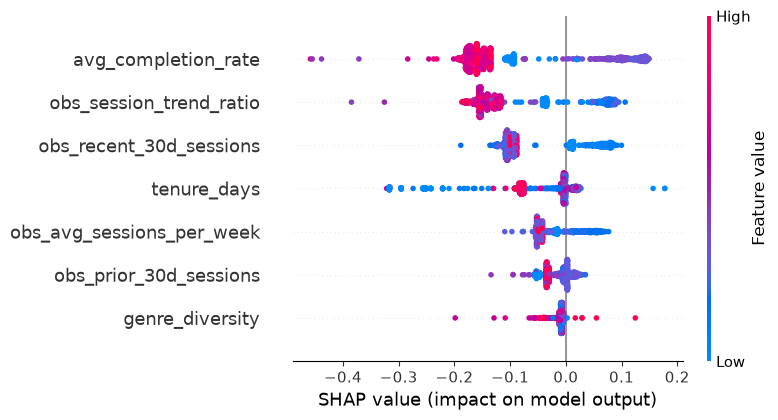

In [4]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)


shap_values_churn = shap_values[:, :, 1]

shap.summary_plot(shap_values_churn, X_test, show=True)

Risk score: 0.9593344259353962
obs_avg_sessions_per_week     0.0
avg_completion_rate           0.0
genre_diversity              13.0
tenure_days                   3.0
obs_recent_30d_sessions       0.0
obs_prior_30d_sessions        0.0
obs_session_trend_ratio       0.0
Name: 2201, dtype: float64


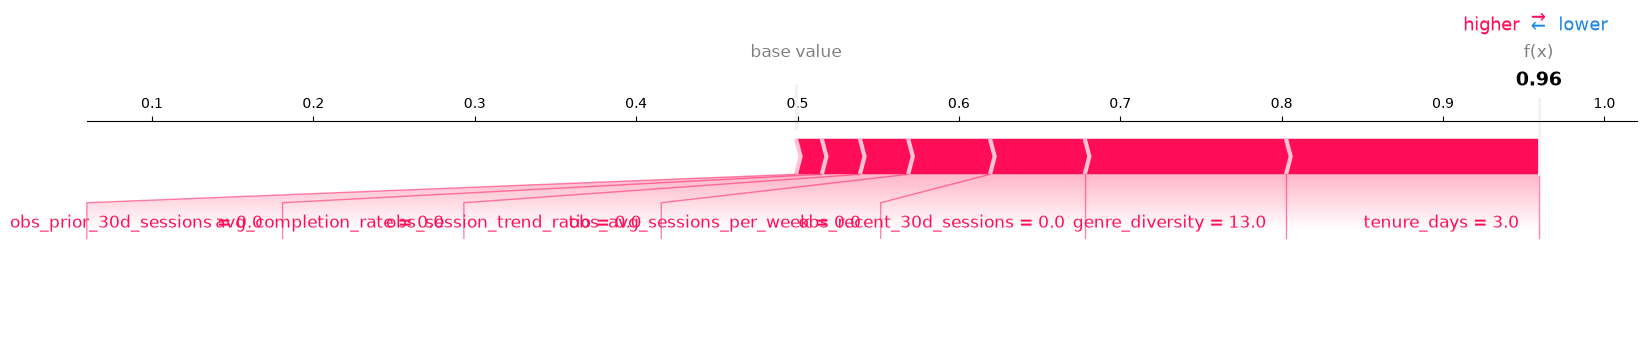

In [5]:
risky_idx = np.argmax(rf.predict_proba(X_test)[:, 1])
print("Risk score:", rf.predict_proba(X_test)[:, 1][risky_idx])
print(X_test.iloc[risky_idx])

shap.force_plot(
    explainer.expected_value[1],
    shap_values_churn[risky_idx],
    X_test.iloc[risky_idx],
    matplotlib=True,
    show=True,
)

In [6]:
print(df.loc[2201, 'persona'])

new_user


### SHAP Interpretation

The three strongest churn drivers are, in order: completion rate, session 
trend ratio, and recent activity level. Low completion rate and declining 
session trends are the model's primary signals consistent with the 
underlying persona design, where Churning Users are characterized by 
declining engagement rather than simply low activity in isolation.

The force plot example (user index 2201, risk score 0.96) is confirmed to 
be a `new_user` persona zero activity across all engagement metrics, 
very short tenure (3 days), and unusually high genre diversity (13), 
consistent with a user who briefly explored the platform before 
disengaging entirely without ever establishing a behavioral pattern. This 
illustrates the cold start risk case flagged in Phase 3: the model 
correctly identifies this user as high risk even without historical 
engagement signal to draw on, based on the short tenure and total 
inactivity alone.

In [7]:
# Make sure this runs BEFORE the export cell below, in the same kernel session
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

# --- NOW the export cell ---
churn_results = X_test.copy()
churn_results['user_id'] = df.loc[X_test.index, 'user_id'].values
churn_results['segment'] = df.loc[X_test.index, 'segment'].values
churn_results['actual_churned'] = y_test.values
churn_results['churn_probability'] = y_pred_proba
churn_results.to_csv("../data/processed/dashboard_churn_risk.csv", index=False)

shap_importance = pd.DataFrame({
    'feature': X_test.columns,
    'mean_abs_shap': np.abs(shap_values_churn).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
shap_importance.to_csv("../data/processed/dashboard_shap_importance.csv", index=False)